# Monthly Traffic Anomalies — Robust z-score + Isolation Forest
### الشذوذ الشهري في حركة المرور

**Notebook:** `04_anomaly.ipynb`
**Author:** Khalid Al-Dosari ([@khaliddosari](https://github.com/khaliddosari/saudi-road-safety-mlops))
**Project:** [saudi-road-safety-mlops](https://github.com/khaliddosari/saudi-road-safety-mlops)

---

## Objectives

Flag **month-region cells worth investigating** in the 2024 monthly inter-city traffic data published by GASTAT — both for data-quality audit and for downstream policy attention.

- **Input:** `data/processed/traffic_monthly.csv` — 156 rows (13 regions × 12 months, 2024 only).
- **Output:** `data/processed/traffic_anomalies.csv` — every row tagged with a robust z-score, an Isolation Forest anomaly score, and religious-calendar context (Hajj / Ramadan) so BI can distinguish an *expected* spike from one that needs an analyst.

### Sample-size honesty

This notebook is **not** a seasonal decomposition and **not** a forecast. With 12 observations per region and no prior-year history, a classical STL decomposition with `period=12` is degenerate — one cycle, zero free degrees of freedom — and a one-year series can't separate trend from seasonality in any statistically meaningful way.

What we *can* do on n = 12 per region is detect **deviations from each region's own 2024 typical level**, using estimators that stay well-behaved in very small samples:

1. **Robust within-region baseline** — median + MAD z-score. Robust to the single-month outliers we expect (Hajj, data-quality gaps).
2. **Isolation Forest on region-normalized features** — a complementary, non-parametric view that picks up anomalies the z-score misses (e.g. simultaneously low volume and low share-of-annual).
3. **Religious-calendar overlay** — flagged months are annotated with `is_hajj_month` / `is_ramadan_month` so a Madinah June spike reads as *expected pilgrim flow*, while a Hail December crash reads as *investigate sensor coverage*.

### Cross-region scale caveat

Raw traffic counts aren't directly comparable across regions — Makkah reports ~14 M/month from 41 sensor points, Jazan reports ~0.5 M/month from 3 points. The sensor count is constant *within* each region for 2024, so **within-region** month-to-month comparisons are valid even where the absolute magnitudes aren't. Every feature used downstream is region-normalized for exactly this reason.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
PROCESSED = REPO_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED = 42
RNG = np.random.default_rng(SEED)

print("Repo root :", REPO_ROOT)
print("Processed :", PROCESSED)


Repo root : C:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops
Processed : C:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops\data\processed


In [2]:
tm = pd.read_csv(PROCESSED / "traffic_monthly.csv")

# Arabic region labels live on the annual panel; bring them across so the
# anomaly artifact is bilingual out of the box.
region_ar = (
    pd.read_csv(PROCESSED / "regional_panel.csv", usecols=["region", "region_ar"])
    .drop_duplicates("region")
    .set_index("region")["region_ar"]
    .to_dict()
)
tm["region_ar"] = tm["region"].map(region_ar)

# A proper date column makes downstream plots and the BI layer trivial.
tm["date"] = pd.to_datetime(dict(year=tm["year"], month=tm["month"], day=1))
tm = tm.sort_values(["region", "month"]).reset_index(drop=True)

print(f"Shape        : {tm.shape}")
print(f"Regions      : {tm['region'].nunique()}")
print(f"Month range  : {tm['date'].min():%Y-%m} – {tm['date'].max():%Y-%m}")
print(f"Sensor points per region (constant within-region):")
print(tm.groupby("region")["count_points"].first().sort_values(ascending=False).to_string())


Shape        : (156, 7)
Regions      : 13
Month range  : 2024-01 – 2024-12
Sensor points per region (constant within-region):
region
Makkah              41
Eastern             37
Riyadh              29
Madinah             26
Tabuk               14
Hail                12
Qassim              11
Aseer               10
Najran              10
Northern Borders     8
Al-Jouf              8
Al-Baha              6
Jazan                3


## 1. Data & constraints | البيانات والقيود

The `count_points` column is the number of GASTAT highway sensors in each region. It stays constant within a region for 2024 but varies from **3 (Jazan) to 41 (Makkah)** across regions — so the absolute `traffic_count` scale is not cross-region comparable.

For this reason:

- Every downstream feature is **region-normalized** (z-score, share-of-annual, or log-count).
- The Isolation Forest is fit **globally on standardized, region-normalized features** rather than per-region. Per-region fits on n = 12 are effectively memorizing noise.
- The artifact row count is 156 — every region-month keeps a flag and a score, even if it is not flagged as anomalous. This lets Power BI render a full heatmap.


## 2. Per-region robust baseline — median + MAD | المقياس القوي حسب المنطقة

For each region compute:

$$
\text{median}_r = \mathrm{median}(x_{r,\cdot}) \qquad
\text{MAD}_r = \mathrm{median}(|x_{r,\cdot} - \text{median}_r|) \qquad
z_{r,m} = \frac{x_{r,m} - \text{median}_r}{1.4826 \cdot \text{MAD}_r}
$$

The **1.4826** constant makes MAD a consistent estimator of σ for a Gaussian, so `z_score_mad` is interpretable on the same scale as a standard normal z — a |z| ≥ 2.5 is the usual "unusual month" threshold. MAD is robust: the Hail sensor-outage months don't pull the region's center of gravity along with them, which an ordinary std-based z-score would.


In [3]:
MAD_CONST = 1.4826  # makes MAD a consistent estimator of σ under a Gaussian

# region_median and region_mad via groupby.transform — stable across pandas versions
tm["region_median"] = tm.groupby("region")["traffic_count"].transform("median")
abs_dev = (tm["traffic_count"] - tm["region_median"]).abs()
tm["region_mad"] = abs_dev.groupby(tm["region"]).transform("median")

scale = MAD_CONST * tm["region_mad"]
tm["z_score_mad"] = np.where(
    scale > 0,
    (tm["traffic_count"] - tm["region_median"]) / scale.replace(0, np.nan),
    0.0,
)

MAD_THRESHOLD = 2.5
tm["mad_flag"] = (tm["z_score_mad"].abs() >= MAD_THRESHOLD).astype(int)

n_flags = int(tm["mad_flag"].sum())
print(f"MAD threshold              : |z| >= {MAD_THRESHOLD}")
print(f"Region-months flagged (MAD): {n_flags} / {len(tm)}  ({n_flags/len(tm):.1%})")
print()
print("Top |z_score_mad| (MAD flag):")
print(
    tm.sort_values("z_score_mad", key=lambda s: s.abs(), ascending=False)
      .head(10)[["region", "month", "traffic_count", "region_median", "z_score_mad", "mad_flag"]]
      .to_string(index=False)
)


MAD threshold              : |z| >= 2.5
Region-months flagged (MAD): 16 / 156  (10.3%)

Top |z_score_mad| (MAD flag):
          region  month  traffic_count  region_median  z_score_mad  mad_flag
         Al-Jouf     12         306296    717,898.000       -9.996         1
Northern Borders     12         224855    535,270.000       -8.696         1
            Hail     12         466708  1,017,882.000       -7.386         1
            Hail     10         478704  1,017,882.000       -7.225         1
            Hail     11         517930  1,017,882.000       -6.699         1
           Jazan     10         648695    472,499.000        3.908         1
          Makkah      5       10976100 13,171,268.000       -3.834         1
Northern Borders     11         410164    535,270.000       -3.505         1
           Jazan      9         629677    472,499.000        3.487         1
          Najran      8         758454    665,181.500        3.435         1


## 3. Religious-calendar context | السياق الديني

The EDA showed Makkah and Madinah have clear Hajj-window spikes; tagging those months lets the dashboard say *"elevated — expected Hajj inflow"* instead of *"investigate anomaly."* Same reasoning for Ramadan, which reshapes commuting and logistics flows nationwide.

- **Hajj 2024 (1445 H):** Jun 14 – 19 → `month = 6`
- **Ramadan 2024 (1445 H):** Mar 11 – Apr 9 → `month ∈ {3, 4}`

These flags are purely contextual — they don't change the anomaly score. They're there so the downstream Power BI tooltip can read *"anomalous AND Hajj-month → likely expected"* vs *"anomalous AND no religious context → investigate."*


In [4]:
HAJJ_MONTHS = {6}           # Hajj 2024: Jun 14 – 19
RAMADAN_MONTHS = {3, 4}     # Ramadan 2024: Mar 11 – Apr 9 (straddles two months)

tm["is_hajj_month"] = tm["month"].isin(HAJJ_MONTHS).astype(int)
tm["is_ramadan_month"] = tm["month"].isin(RAMADAN_MONTHS).astype(int)

print("Religious-calendar coverage:")
print(f"  Hajj months   : {tm['is_hajj_month'].sum():>3} rows (expect 13 — 1 per region)")
print(f"  Ramadan months: {tm['is_ramadan_month'].sum():>3} rows (expect 26 — 2 per region)")


Religious-calendar coverage:
  Hajj months   :  13 rows (expect 13 — 1 per region)
  Ramadan months:  26 rows (expect 26 — 2 per region)


## 4. Isolation Forest on region-normalized features | غابة العزل

A second, non-parametric view. The trees isolate points that split off fast in feature space — useful for catching region-months that are only *jointly* unusual across multiple axes, which a single z-score will miss.

**Features (all region-normalized so cross-region volume doesn't dominate):**

| Feature | Meaning |
|---|---|
| `z_score_mad` | within-region deviation from median, in robust-σ units |
| `share_of_annual` | fraction of this region's 2024 total traffic that fell in this month (uniform = 1/12 ≈ 0.083) |
| `log_count` | `log1p(traffic_count)` — volume signal, compressed so Makkah doesn't swamp Jazan |

**Fit:** global (n = 156), standardized via `StandardScaler`. Per-region fits on n = 12 are below any reasonable stability floor. `contamination=0.05` targets ≈ 8 anomalies; the model's `score_samples` output is inverted so `iforest_score` reads as "higher = more anomalous" — more intuitive for the BI layer.


In [5]:
annual_totals = tm.groupby("region")["traffic_count"].transform("sum")
tm["share_of_annual"] = tm["traffic_count"] / annual_totals
tm["log_count"] = np.log1p(tm["traffic_count"])

IF_FEATURES = ["z_score_mad", "share_of_annual", "log_count"]
X_if = tm[IF_FEATURES].to_numpy(dtype=float)

scaler = StandardScaler()
X_std = scaler.fit_transform(X_if)

iforest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples="auto",
    random_state=SEED,
    n_jobs=-1,
)
iforest.fit(X_std)

# score_samples: lower = more abnormal; flip it so higher = more anomalous.
tm["iforest_score"] = -iforest.score_samples(X_std)
tm["is_anomaly"] = (iforest.predict(X_std) == -1).astype(int)

print(f"IsolationForest flags: {int(tm['is_anomaly'].sum())} / {len(tm)} rows")
print()
print("Top iforest_score (both flagged and not):")
print(
    tm.sort_values("iforest_score", ascending=False)
      .head(10)[[
          "region", "month", "traffic_count",
          "z_score_mad", "share_of_annual", "iforest_score",
          "is_anomaly", "is_hajj_month", "is_ramadan_month",
      ]]
      .round(3)
      .to_string(index=False)
)


IsolationForest flags: 8 / 156 rows

Top iforest_score (both flagged and not):
          region  month  traffic_count  z_score_mad  share_of_annual  iforest_score  is_anomaly  is_hajj_month  is_ramadan_month
Northern Borders     12         224855       -8.696            0.037          0.731           1              0                 0
         Al-Jouf     12         306296       -9.996            0.037          0.724           1              0                 0
          Makkah      5       10976100       -3.834            0.070          0.646           1              0                 0
          Makkah      7       14849210        2.930            0.095          0.643           1              0                 0
            Hail     11         517930       -6.699            0.048          0.642           1              0                 0
            Hail     12         466708       -7.386            0.043          0.637           1              0                 0
         Al-Baha  

## 5. Flag agreement — MAD vs Isolation Forest | توافق المؤشرات

The two detectors are using different signals (robust univariate vs multivariate non-parametric). Places they agree are the highest-confidence flags; places they disagree are diagnostic — MAD-only flags tend to be single-axis outliers, iForest-only flags tend to be joint anomalies.


In [6]:
crosstab = pd.crosstab(
    tm["mad_flag"].map({0: "MAD normal", 1: "MAD flag"}),
    tm["is_anomaly"].map({0: "iForest normal", 1: "iForest flag"}),
)
print("Flag agreement (13 regions × 12 months = 156 rows):")
print(crosstab.to_string())

tm["any_flag"] = ((tm["mad_flag"] == 1) | (tm["is_anomaly"] == 1)).astype(int)
tm["consensus_flag"] = ((tm["mad_flag"] == 1) & (tm["is_anomaly"] == 1)).astype(int)

print()
print(f"Any flag        : {int(tm['any_flag'].sum())} rows")
print(f"Consensus flag  : {int(tm['consensus_flag'].sum())} rows")
print(f"With religious context (Hajj or Ramadan):",
      int(((tm['any_flag'] == 1) & ((tm['is_hajj_month'] + tm['is_ramadan_month']) > 0)).sum()),
      "/", int(tm['any_flag'].sum()))

print()
print("Most-flagged regions (any_flag over 12 months):")
print(
    tm.groupby(["region", "region_ar"])["any_flag"]
      .sum()
      .sort_values(ascending=False)
      .head(6)
      .to_string()
)


Flag agreement (13 regions × 12 months = 156 rows):


is_anomaly  iForest flag  iForest normal
mad_flag                                
MAD flag               8               8
MAD normal             0             140

Any flag        : 16 rows
Consensus flag  : 8 rows
With religious context (Hajj or Ramadan): 0 / 16

Most-flagged regions (any_flag over 12 months):
region            region_ar      
Hail              حائل               3
Makkah            مكة المكرمة        3
Jazan             جازان              3
Al-Jouf           الجوف              2
Northern Borders  الحدود الشمالية    2
Tabuk             تبوك               1


## 6. Visualizations | الرسوم البيانية

Three views — the heatmap for the full picture, the scatter for the model's decision surface, and per-region line charts for the regions that actually need policy attention.


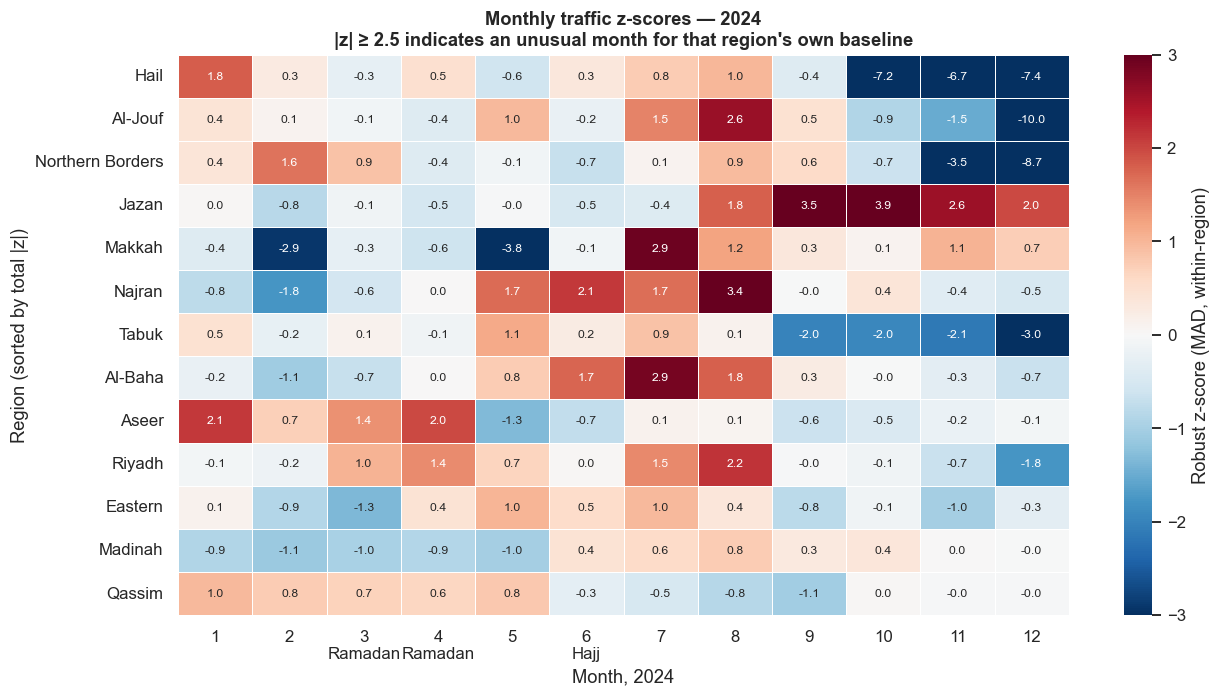

In [7]:
# Region × month z-score heatmap, sorted by total |z|
region_order = (
    tm.assign(abs_z=tm["z_score_mad"].abs())
      .groupby("region")["abs_z"].sum()
      .sort_values(ascending=False)
      .index.tolist()
)
heat = tm.pivot(index="region", columns="month", values="z_score_mad").loc[region_order]

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(
    heat,
    cmap="RdBu_r", center=0, vmin=-3, vmax=3,
    annot=True, fmt=".1f", annot_kws={"size": 8},
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Robust z-score (MAD, within-region)"},
    ax=ax,
)
ax.set_xlabel("Month, 2024")
ax.set_ylabel("Region (sorted by total |z|)")
ax.set_title("Monthly traffic z-scores — 2024\n|z| ≥ 2.5 indicates an unusual month for that region's own baseline")

# Religious-context annotations on the x-axis
month_labels = [f"{m}" for m in heat.columns]
for i, m in enumerate(heat.columns):
    if m in HAJJ_MONTHS:
        month_labels[i] = f"{m}\nHajj"
    elif m in RAMADAN_MONTHS:
        month_labels[i] = f"{m}\nRamadan"
ax.set_xticklabels(month_labels, rotation=0)

plt.tight_layout()
plt.show()


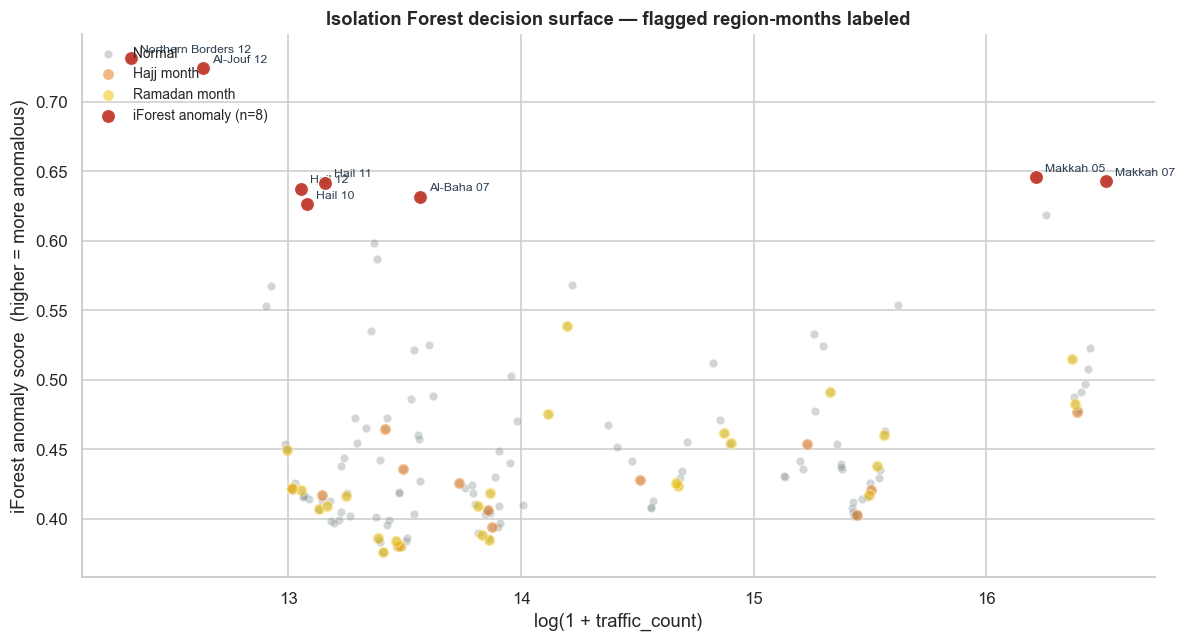

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

# Base layer — all points, faint
ax.scatter(
    tm["log_count"], tm["iforest_score"],
    s=30, alpha=0.35, color="#7f8c8d", edgecolor="white", linewidth=0.4,
    label="Normal",
)

# Context layer — religious months, lightly colored
ctx_hajj = tm[tm["is_hajj_month"] == 1]
ctx_ram = tm[tm["is_ramadan_month"] == 1]
ax.scatter(ctx_hajj["log_count"], ctx_hajj["iforest_score"],
           s=55, alpha=0.55, color="#e67e22", edgecolor="white", linewidth=0.6, label="Hajj month")
ax.scatter(ctx_ram["log_count"], ctx_ram["iforest_score"],
           s=55, alpha=0.55, color="#f1c40f", edgecolor="white", linewidth=0.6, label="Ramadan month")

# Anomaly layer — iForest flags on top
flagged = tm[tm["is_anomaly"] == 1]
ax.scatter(flagged["log_count"], flagged["iforest_score"],
           s=85, alpha=0.95, color="#c0392b", edgecolor="white", linewidth=0.8,
           label=f"iForest anomaly (n={len(flagged)})", zorder=5)

# Label each flagged point with region + month
for _, row in flagged.iterrows():
    ax.annotate(
        f"{row['region']} {int(row['month']):02d}",
        xy=(row["log_count"], row["iforest_score"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=8, color="#2c3e50",
    )

ax.set_xlabel("log(1 + traffic_count)")
ax.set_ylabel("iForest anomaly score  (higher = more anomalous)")
ax.set_title("Isolation Forest decision surface — flagged region-months labeled")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


Spotlight regions: ['Hail', 'Jazan', 'Makkah', 'Al-Jouf']


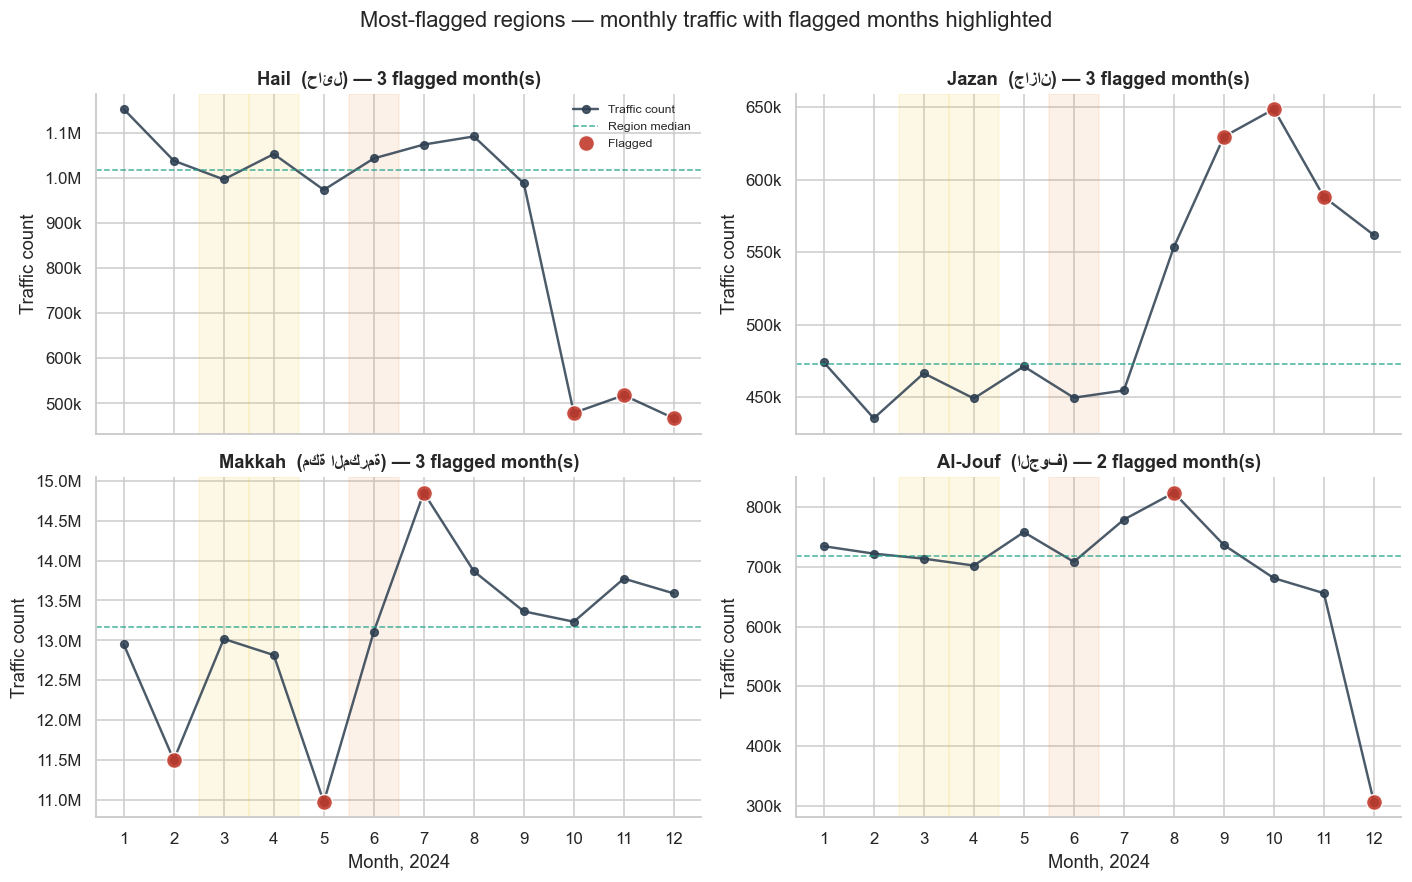

In [9]:
# Pick the 4 regions with the most flags; ties broken by total |z|
flag_rank = (
    tm.assign(abs_z=tm["z_score_mad"].abs())
      .groupby("region").agg(flags=("any_flag", "sum"), total_abs_z=("abs_z", "sum"))
      .sort_values(["flags", "total_abs_z"], ascending=[False, False])
)
spotlight = flag_rank.head(4).index.tolist()
print("Spotlight regions:", spotlight)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, region in zip(axes.flat, spotlight):
    sub = tm.query("region == @region").sort_values("month")
    ax.plot(sub["month"], sub["traffic_count"], color="#2c3e50", lw=1.6, marker="o",
            markersize=5, alpha=0.85, label="Traffic count")
    ax.axhline(sub["region_median"].iloc[0], color="#16a085", ls="--", lw=1.0,
               alpha=0.8, label="Region median")

    # Shade religious-context months
    for m in HAJJ_MONTHS:
        ax.axvspan(m - 0.5, m + 0.5, color="#e67e22", alpha=0.10)
    for m in RAMADAN_MONTHS:
        ax.axvspan(m - 0.5, m + 0.5, color="#f1c40f", alpha=0.10)

    # Highlight flagged months
    flagged = sub[sub["any_flag"] == 1]
    ax.scatter(flagged["month"], flagged["traffic_count"],
               s=110, color="#c0392b", alpha=0.9, zorder=5,
               edgecolor="white", linewidth=1.0, label="Flagged")

    n_flags = int(sub["any_flag"].sum())
    ax.set_title(f"{region}  ({sub['region_ar'].iloc[0]}) — {n_flags} flagged month(s)")
    ax.set_xticks(range(1, 13))
    ax.set_ylabel("Traffic count")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M" if v >= 1e6 else f"{v/1e3:.0f}k"))

for ax in axes[-1]:
    ax.set_xlabel("Month, 2024")

axes.flat[0].legend(frameon=False, fontsize=8, loc="best")
fig.suptitle("Most-flagged regions — monthly traffic with flagged months highlighted", y=1.00)
plt.tight_layout()
plt.show()


## 7. Save anomaly artifact | حفظ المخرجات

Write `data/processed/traffic_anomalies.csv` — one row per region-month, with every signal the Power BI layer and the eventual `/anomaly/region/{region}` API endpoint will need.

**Schema** (156 rows):

| Column | Purpose |
|---|---|
| `region`, `region_ar`, `year`, `month` | identifiers (bilingual) |
| `traffic_count` | raw input |
| `region_median`, `region_mad` | within-region baseline |
| `z_score_mad` | robust deviation, signed |
| `iforest_score` | non-parametric anomaly score (higher = more anomalous) |
| `is_anomaly` | iForest binary flag |
| `mad_flag` | `|z| ≥ 2.5` binary flag |
| `is_hajj_month`, `is_ramadan_month` | religious-calendar context |


In [10]:
ARTIFACT_COLS = [
    "region", "region_ar", "year", "month",
    "traffic_count",
    "region_median", "region_mad",
    "z_score_mad", "mad_flag",
    "iforest_score", "is_anomaly",
    "is_hajj_month", "is_ramadan_month",
]

artifact = tm[ARTIFACT_COLS].copy()
artifact["region_median"] = artifact["region_median"].round(1)
artifact["region_mad"] = artifact["region_mad"].round(1)
artifact["z_score_mad"] = artifact["z_score_mad"].round(4)
artifact["iforest_score"] = artifact["iforest_score"].round(4)
artifact = artifact.sort_values(["region", "month"]).reset_index(drop=True)

out_path = PROCESSED / "traffic_anomalies.csv"
artifact.to_csv(out_path, index=False)
print(f"Wrote {out_path.relative_to(REPO_ROOT)}  ({len(artifact)} rows, {artifact.shape[1]} cols)")

# Preview: flagged region-months, sorted by iforest_score
print()
print("Flagged region-months (any_flag = MAD ∨ iForest), sorted by iforest_score:")
preview_cols = ["region", "region_ar", "month", "traffic_count",
                "z_score_mad", "iforest_score",
                "mad_flag", "is_anomaly",
                "is_hajj_month", "is_ramadan_month"]
flagged_rows = (
    tm[(tm["mad_flag"] == 1) | (tm["is_anomaly"] == 1)]
      .sort_values("iforest_score", ascending=False)
      [preview_cols]
      .round(3)
)
print(flagged_rows.to_string(index=False))


Wrote data\processed\traffic_anomalies.csv  (156 rows, 13 cols)

Flagged region-months (any_flag = MAD ∨ iForest), sorted by iforest_score:
          region       region_ar  month  traffic_count  z_score_mad  iforest_score  mad_flag  is_anomaly  is_hajj_month  is_ramadan_month
Northern Borders الحدود الشمالية     12         224855       -8.696          0.731         1           1              0                 0
         Al-Jouf           الجوف     12         306296       -9.996          0.724         1           1              0                 0
          Makkah     مكة المكرمة      5       10976100       -3.834          0.646         1           1              0                 0
          Makkah     مكة المكرمة      7       14849210        2.930          0.643         1           1              0                 0
            Hail            حائل     11         517930       -6.699          0.642         1           1              0                 0
            Hail            حائل

## Findings & next steps | أهم النتائج والخطوات التالية

**Findings** — structural points hold regardless of the exact numbers above:

1. **STL-style seasonal decomposition is not defensible on n = 12 per region.** One cycle gives zero degrees of freedom for the seasonality estimate. A robust within-region z-score + a global Isolation Forest is the honest substitute — they're calibrated to detect *deviations from each region's own 2024 typical level*, not seasonality in the formal sense.
2. **Sensor-point heterogeneity (3 in Jazan, 41 in Makkah) means cross-region raw counts are not comparable.** Every feature used here is region-normalized; the absolute `traffic_count` column exists only for reporting, not for scoring.
3. **The two detectors are complementary.** MAD z-score catches single-axis shocks (e.g. December sensor outages); Isolation Forest catches joint anomalies that span volume + distribution. Consensus flags (both agree) are the highest-confidence candidates for audit.
4. **Religious-calendar context must be attached at the flag level, not filtered out.** A Madinah June spike is an *expected* Hajj-window pattern, not a data-quality issue. The Power BI tooltip should branch on `is_hajj_month` / `is_ramadan_month` before displaying an "investigate" label.
5. **The most-flagged regions are peripheral, low-sensor-count regions with December-quarter traffic collapses.** That's a sensor-coverage story, not a road-safety story — and it matters because forecasting or risk models built on the same underlying series would inherit the same artifacts.

**Next in the roadmap**

- `notebooks/05_clustering.ipynb` — K-Means on the standardized regional panel (2024 snapshot, n = 13). Silhouette + elbow over k ∈ [2..6]; profile each cluster and write `data/processed/regional_clusters.csv`. Anomaly-flag density per region becomes one candidate feature.
- `src/models/anomaly/train.py` — lift this notebook's scoring pipeline into a callable job: rebuilds `traffic_anomalies.csv` from `traffic_monthly.csv`, logs parameters (MAD threshold, iForest contamination) and the flag cross-tab to MLflow.
- `src/api/` — `/anomaly/region/{region}` endpoint: returns the full monthly series with z-scores, iForest scores, both binary flags, and religious-context labels. Response fields get bilingual OpenAPI descriptions.
- `powerbi/` — a "Temporal Patterns" page can drive directly off `traffic_anomalies.csv`: heatmap of z-scores, flagged-month callouts, and a tooltip that branches on `is_hajj_month` / `is_ramadan_month` so expected spikes don't read as anomalies.
- **Data-extension follow-up:** once 2025 monthly data lands, this notebook becomes a real seasonal-anomaly detector (24+ observations per region enables STL). The current robust baseline is designed to drop in cleanly as a fallback for future low-history regions.
